<center>


<div style="display: flex; justify-content: center;">
    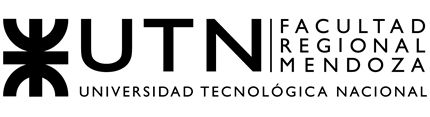
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Departamento de Ingeniería en Tecnologías Electrónicas</strong></p>
    </div>
</center>

# Laboratorio n° 2: Convolución

**Asignatura:** Análisis de Señales y Sistemas
**Requisitos previos:** Módulos 1 a 9, Laboratorio 0 y Laboratorio 1

---

## Introducción

En el Laboratorio 1 construiste señales y las manipulaste de a una: las desplazaste, las reflejaste, las escalaste, las sumaste y las multiplicaste punto a punto. Este laboratorio combina esas operaciones en una sola, la **convolución**, y les da un significado nuevo: dejan de ser manipulaciones sueltas y pasan a describir **qué le hace un sistema a una señal**.

La idea es la siguiente. Muchos sistemas físicos —un circuito, un recinto, un sensor, un canal de comunicación— son **lineales e invariantes en el tiempo** (LTI). Un sistema así queda completamente caracterizado por una única señal: su **respuesta al impulso**, que se anota $h(t)$ en tiempo continuo y $h[n]$ en tiempo discreto. Es lo que el sistema entrega cuando se lo excita con un estímulo muy breve y muy intenso. Conocida esa respuesta, la salida ante **cualquier** entrada se obtiene convolucionando la entrada con ella:

$$y[n] = \sum_{k=-\infty}^{\infty} x[k]\,h[n-k]$$

Lo notable es que esa fórmula, que parece abstracta, es exactamente lo que ya sabés hacer: reflejar $h$, desplazarla, multiplicarla punto a punto por $x$ y sumar. Una operación del Laboratorio 1 por cada símbolo de la ecuación.

El laboratorio termina en algo que se puede escuchar. Vamos a medir la respuesta al impulso de un espacio grande y reverberante —grabando un sonido breve y muy intenso dentro de él— y a convolucionarla con la grabación de un violín hecha en un estudio. El resultado es cómo habría sonado ese violín si lo hubieran tocado en ese espacio.

Al completar este laboratorio vas a poder:

- Implementar la convolución discreta a partir de su definición y explicar por qué el resultado dura más que las señales de entrada.
- Interpretar la convolución como reflejar, desplazar, multiplicar y sumar, y relacionarla con las operaciones del Laboratorio 1.
- Usar `np.convolve` y `scipy.signal.convolve`, y elegir entre los modos `full`, `same` y `valid`.
- Verificar numéricamente la linealidad y la invarianza en el tiempo de un sistema descripto por su respuesta al impulso.
- Aplicar la respuesta al impulso medida de un recinto a una señal de audio y evaluar el resultado escuchándolo.
- Extender la convolución a dos dimensiones y aplicarla al procesamiento de imágenes.

---

## Instrucciones generales

- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto (tipo Markdown).
- Ejecutá las celdas en orden: varios ejercicios reutilizan variables definidas en ejercicios anteriores.
- Varios ejercicios generan sonido. Si estás en un entorno sin audio, el gráfico alcanza para resolverlos.

## IMPORTANTE: qué celdas podés modificar

Este laboratorio es un **entregable**. Solo debés completar las celdas de actividad, que son las que aparecen con el comentario `# Tu código aquí` o el texto `*(Escribí tu respuesta acá)*`. Todas las demás celdas (enunciados, explicaciones, ejemplos provistos y el encabezado) **no deben modificarse**: la corrección se hace celda por celda de manera automática y alterar lo que no corresponde puede invalidar tu entrega.

Si necesitás probar algo fuera de una celda de actividad, hacelo en una copia aparte y revertí los cambios antes de entregar.

---
## Preparación

Ejecutá las dos celdas que siguen **una sola vez** al empezar.

La primera importa las librerías. Además de NumPy y Matplotlib, que ya conocés de los Módulos 7 y 8, aparecen tres piezas nuevas:

- **`scipy.signal`** contiene las funciones de procesamiento de señales de SciPy. Vamos a usar `signal.convolve` para señales largas y `signal.convolve2d` para imágenes.
- **`scipy.io.wavfile.read`** lee un archivo de audio en formato `.wav` y lo devuelve como un array de NumPy.
- **`skimage.data`** provee imágenes de muestra para la última sección.

La segunda celda descarga los dos archivos de audio del laboratorio y los guarda en una carpeta `audios`. Si ya están descargados, no vuelve a bajarlos.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Módulo de procesamiento de señales de SciPy: convolución de señales largas
# (signal.convolve) y de imágenes (signal.convolve2d).
from scipy import signal

# Lectura de archivos .wav.
from scipy.io.wavfile import read

# Reproducción de audio dentro del notebook, igual que en el Laboratorio 1.
from IPython.display import Audio

# Imágenes de muestra para la sección de convolución en dos dimensiones.
from skimage import data

print(f"Versión de NumPy: {np.__version__}")

In [ ]:
import os
import urllib.request

URL_BASE = "https://raw.githubusercontent.com/ASyS-utn-frm/python/main/resources/audios/"
ARCHIVOS = ("impulsiva_galpon.wav", "violin.wav")

os.makedirs("audios", exist_ok=True)

for nombre in ARCHIVOS:
    destino = os.path.join("audios", nombre)
    if not os.path.exists(destino):
        urllib.request.urlretrieve(URL_BASE + nombre, destino)
    print(f"{destino}: {os.path.getsize(destino) / 1024:.0f} kB")

---
## Sección A: La convolución discreta, paso a paso

Antes de aplicar la convolución a señales de cientos de miles de muestras conviene calcularla sobre señales de cinco, donde cada número se puede seguir a mano.

Trabajamos con dos señales de tiempo discreto:

- **`x`**, la **entrada**: una ráfaga corta de cinco muestras.
- **`h`**, la **respuesta al impulso** del sistema: tres muestras que representan un recinto muy simple, uno que devuelve el sonido directo y dos reflexiones cada vez más débiles.

La definición de la convolución discreta es

$$y[n] = \sum_{k=-\infty}^{\infty} x[k]\,h[n-k]$$

En la práctica la suma no es infinita: fuera del rango en el que las señales están definidas todos los términos valen cero. Si `x` tiene $N_x$ muestras y `h` tiene $N_h$, el resultado tiene exactamente

$$N_y = N_x + N_h - 1$$

muestras. Uno de los ejercicios de esta sección es explicar de dónde sale ese número.

Un detalle de notación: en esta sección los índices son **números de muestra**, no segundos. Por eso los gráficos se hacen con `plt.stem` y no con `plt.plot`: `stem` dibuja una línea vertical por muestra, que es lo correcto cuando las señales son intrínsecamente discretas y no provienen de muestrear algo continuo.

### Ejercicio 1 — Convolución a partir de la definición

**Objetivo:** Implementar la convolución discreta con bucles y verificar la longitud del resultado.

**Enunciado:**

1. Definí las dos señales como arrays de NumPy:
   - `x = [1.0, 2.0, 3.0, 2.0, 1.0]` — la ráfaga de entrada.
   - `h = [1.0, 0.5, 0.25]` — el sonido directo y dos reflexiones atenuadas.
2. Escribí una función `convolucion(x, h)` que calcule la convolución **a partir de la definición**, con dos bucles `for` anidados: uno que recorra el índice `n` del resultado y otro que recorra el índice `k` de la suma. La función debe devolver un array de NumPy de longitud `len(x) + len(h) - 1`.
3. Calculá `y = convolucion(x, h)` e imprimí las longitudes de las tres señales y los valores de `y`.
4. Graficá `x`, `h` e `y` con `plt.stem` en tres paneles, uno debajo del otro. Ponele a cada panel su título, etiquetas en los ejes y grilla.

> **Pista 1:** creá el array de salida con `np.zeros(len(x) + len(h) - 1)` y acumulá sobre él con `+=`.
>
> **Pista 2:** el término `h[n - k]` solo existe cuando `n - k` cae dentro de `h`, es decir cuando `0 <= n - k < len(h)`. Si no verificás esa condición vas a leer posiciones que no corresponden: en Python un índice negativo cuenta desde el final del array y no da error, así que el cálculo saldría mal **sin avisar**.
>
> **Pista 3:** el eje horizontal de cada panel es el número de muestra. Se genera con `np.arange(len(señal))`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

La entrada dura 5 muestras y la respuesta al impulso, 3; la salida dura 7. Explicá, en términos de lo que representa cada señal —una ráfaga que entra a un recinto que devuelve dos reflexiones—, por qué la salida dura más que la entrada y por qué su longitud es exactamente $N_x + N_h - 1$ y no $N_x + N_h$.

*(Escribí tu respuesta acá)*

### Ejercicio 2 — La versión de NumPy, y por qué conviene usarla

**Objetivo:** Contrastar la implementación propia con `np.convolve` y medir la diferencia de rendimiento.

La función del ejercicio 1 es correcta, pero es lenta: recorre las señales muestra por muestra desde Python. NumPy provee `np.convolve(x, h)`, que hace exactamente lo mismo con código compilado. En el Módulo 7 viste esa misma idea aplicada a la aritmética: las operaciones vectorizadas evitan los bucles de Python y por eso corren mucho más rápido.

**Enunciado:**

1. Calculá `y_numpy = np.convolve(x, h)` y verificá que coincide con el resultado del ejercicio 1 usando `np.allclose`. Imprimí el resultado de la comparación.
2. Generá dos señales largas de prueba con un generador de números aleatorios de semilla fija:
   ```
   rng = np.random.default_rng(0)
   x_largo = rng.normal(size=1500)
   h_largo = rng.normal(size=150)
   ```
3. Medí cuánto tarda cada una de las dos implementaciones sobre esas señales largas, usando `time.perf_counter()` antes y después de cada llamada. Importá `time` en esta misma celda.
4. Imprimí los dos tiempos en segundos y cuántas veces más rápida resultó `np.convolve`.
5. Verificá con `np.allclose` que las dos implementaciones dan el mismo resultado también sobre las señales largas.

> **Pista:** `time.perf_counter()` devuelve un número de segundos. La duración de un cálculo es la diferencia entre el valor tomado después y el tomado antes.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Las dos implementaciones calculan lo mismo y dan el mismo resultado, pero una tarda órdenes de magnitud más que la otra. Explicá a qué se debe la diferencia. Estimá además cuántas multiplicaciones hay que hacer para convolucionar dos señales de $N_x$ y $N_h$ muestras, y usá esa estimación para justificar por qué la implementación con bucles resulta impracticable con los audios de la sección C, donde $N_x \approx 220\,000$ y $N_h \approx 94\,000$.

*(Escribí tu respuesta acá)*

### La convolución como reflejar, desplazar, multiplicar y sumar

La definición $y[n] = \sum_k x[k]\,h[n-k]$ se puede leer como una receta de cuatro pasos, y los cuatro son operaciones del Laboratorio 1:

1. **Reflejar** la respuesta al impulso: en lugar de $h[k]$ aparece $h[-k]$.
2. **Desplazarla** $n$ muestras hacia la derecha: $h[n-k]$.
3. **Multiplicar** punto a punto por la entrada: $x[k]\,h[n-k]$.
4. **Sumar** todos los productos: eso da un único número, $y[n]$.

Repitiendo el procedimiento para cada $n$ se obtiene la salida completa. Por eso a esta lectura se la llama *flip and slide*: reflejar y deslizar.

La celda que sigue define dos ayudas para ver el procedimiento en acción. No hay nada que completar: ejecutala y observá los gráficos.

- `h_reflejada_desplazada(h, n, largo)` devuelve el array $h[n-k]$ evaluado sobre los índices $k = 0, 1, \dots, largo-1$, es decir sobre el mismo eje de índices que tiene la entrada.
- `dibujar_paso(x, h, n)` grafica, para un $n$ dado, la entrada, la respuesta al impulso reflejada y desplazada, y el producto de ambas. El área sombreada del panel inferior es lo que se suma para obtener $y[n]$.

In [ ]:
def h_reflejada_desplazada(h, n, largo):
    """Devuelve h[n - k] evaluado en k = 0, 1, ..., largo - 1.

    Las posiciones en las que n - k cae fuera de h quedan en cero, porque ahí
    la señal no está definida y no aporta a la suma.
    """
    resultado = np.zeros(largo)
    for k in range(largo):
        if 0 <= n - k < len(h):
            resultado[k] = h[n - k]
    return resultado


def dibujar_paso(x, h, n):
    """Grafica los tres pasos del cálculo de y[n] para un n dado."""
    k = np.arange(len(x))
    h_desp = h_reflejada_desplazada(h, n, len(x))
    producto = x * h_desp

    fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

    axs[0].stem(k, x)
    axs[0].set_title("Entrada $x[k]$")
    axs[0].set_ylabel("Amplitud")
    axs[0].grid(True)

    axs[1].stem(k, h_desp, linefmt="tab:orange", markerfmt="o")
    axs[1].set_title(f"Respuesta al impulso reflejada y desplazada: $h[{n}-k]$")
    axs[1].set_ylabel("Amplitud")
    axs[1].grid(True)

    axs[2].stem(k, producto, linefmt="tab:green", markerfmt="o")
    axs[2].fill_between(k, 0, producto, color="tab:green", alpha=0.2)
    axs[2].set_title(f"Producto $x[k]\\,h[{n}-k]$ — su suma vale y[{n}] = {producto.sum():.2f}")
    axs[2].set_xlabel("Índice $k$")
    axs[2].set_ylabel("Amplitud")
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()


# Ejemplo: el cálculo de y[1] sobre las señales del ejercicio 1.
dibujar_paso(x, h, 1)

### Ejercicio 3 — Reflejar, desplazar y sumar

**Objetivo:** Calcular una muestra de la salida siguiendo los cuatro pasos, sin usar la fórmula de convolución completa.

**Enunciado:**

1. Usando `h_reflejada_desplazada`, construí el array $h[3-k]$ sobre el mismo eje de índices que `x`, y guardalo en `h_desp_3`.
2. Calculá el producto punto a punto de `x` con ese array y guardalo en `producto_3`.
3. Obtené `y_3` sumando todos los elementos del producto, e imprimí el valor.
4. Verificá que `y_3` coincide con `np.convolve(x, h)[3]`. Imprimí los dos valores.
5. Llamá a `dibujar_paso(x, h, 3)` para visualizar el procedimiento.
6. Repetí los pasos 1 a 3 para `n = 6` y para `n = 7`, e imprimí los dos valores obtenidos.

> **Pista:** para sumar todos los elementos de un array usá el método `.sum()`, como en el Módulo 7.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las dos partes:

1. En la fórmula, el índice de la respuesta al impulso es $n-k$ y no $k-n$. Explicá qué operación del Laboratorio 1 introduce el signo negativo delante de $k$ y qué operación introduce el $n$, y por qué el orden en que se aplican produce el desplazamiento hacia la derecha que se ve en el panel del medio.
2. El valor de `y[7]` que obtuviste en el paso 6 es cero, aunque la fórmula se puede evaluar sin ningún error. Explicá por qué, y relacionalo con la longitud del resultado que discutiste en el ejercicio 1.

*(Escribí tu respuesta acá)*

---
## Sección B: Sistemas LTI y respuesta al impulso

Hasta acá la convolución fue una operación entre dos arrays. En esta sección pasa a ser lo que **describe un sistema**.

Un sistema es lineal e invariante en el tiempo cuando cumple dos condiciones:

- **Linealidad:** si la entrada es una combinación $a\,x_1[n] + b\,x_2[n]$, la salida es la misma combinación de las salidas individuales, $a\,y_1[n] + b\,y_2[n]$.
- **Invarianza en el tiempo:** si la entrada se retarda $D$ muestras, la salida es la misma, retardada las mismas $D$ muestras. El sistema se comporta hoy igual que ayer.

Cuando ambas se cumplen, la salida ante cualquier entrada es la convolución de esa entrada con la respuesta al impulso. Eso es lo que hace tan útil a $h[n]$: una sola medición —la respuesta a un estímulo breve— alcanza para predecir la respuesta a todo lo demás.

**Los tres modos de `np.convolve`.** Hasta ahora usamos el resultado completo, de $N_x + N_h - 1$ muestras. El argumento `mode` permite elegir qué tramo se devuelve:

- `mode='full'` (el valor por omisión) devuelve la convolución completa.
- `mode='same'` devuelve el tramo **central**, de la misma longitud que `x`. Es cómodo cuando se quiere comparar la entrada con la salida sobre el mismo eje.
- `mode='valid'` devuelve solamente las muestras en las que las dos señales se superponen por completo, sin depender del relleno de ceros de los bordes. Es la más corta de las tres.

### Ejercicio 4 — Un promediador móvil sobre una medición ruidosa

**Objetivo:** Aplicar una respuesta al impulso sencilla y evaluar el compromiso entre reducir el ruido y conservar la forma de la señal.

Un transistor de potencia tiene un sensor de temperatura pegado a su disipador. La medición se toma una vez por segundo durante 300 segundos. El transistor arranca apagado, a temperatura ambiente, y a los 100 segundos se lo pone en conducción: el disipador se calienta hasta estabilizarse unos 15 °C por encima del ambiente. El sensor es económico y su lectura viene con ruido.

El **promediador móvil** es el sistema LTI más simple que existe: su salida en cada instante es el promedio de las últimas $N$ muestras de la entrada. Su respuesta al impulso es un array de $N$ muestras que valen todas $1/N$.

**Enunciado:**

1. Ejecutá esta parte tal cual para generar la medición (copiala en tu celda):
   ```
   rng_temp = np.random.default_rng(7)
   tiempo = np.arange(300)
   calentamiento = np.clip(tiempo - 100, 0, None)
   temperatura_real = 25 + 15 * (1 - np.exp(-calentamiento / 30))
   medicion = temperatura_real + rng_temp.normal(0, 1.2, size=tiempo.size)
   ```
2. Construí dos respuestas al impulso de promediador móvil: `h_corto` con $N = 5$ y `h_largo_mm` con $N = 51$.
3. Filtrá `medicion` con cada una usando `np.convolve` con `mode='same'`, y guardá los resultados en `suave_5` y `suave_51`.
4. Graficá en un solo panel las cuatro curvas contra `tiempo`: la medición ruidosa, las dos versiones suavizadas y la temperatura real. Ponele título, etiquetas en los ejes, grilla y leyenda.
5. Calculá e imprimí, para la medición y para cada versión suavizada, el error cuadrático medio respecto de `temperatura_real` sobre **dos tramos distintos**:
   - `[200:260]`, donde la temperatura ya está estabilizada;
   - `[60:260]`, que incluye además toda la transición de los 100 segundos.

   Los dos dejan afuera los bordes del eje.

> **Pista 1:** un array de $N$ elementos que valen todos $1/N$ se construye con `np.ones(N) / N`.
>
> **Pista 2:** el error cuadrático medio entre dos arrays `a` y `b` es `np.mean((a - b) ** 2)`.
>
> **Pista 3:** para que la medición ruidosa no tape a las demás curvas, dibujala con transparencia: `alpha=0.4`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las tres partes:

1. Comparando las dos curvas suavizadas, describí qué mejora y qué empeora al pasar de $N = 5$ a $N = 51$. Prestá atención a que el orden de los errores cuadráticos medios **se invierte** entre los dos tramos: explicá por qué.
2. En los extremos del eje, cerca de $t = 0$ y de $t = 300$ s, la curva con $N = 51$ se aparta de las demás y cae hacia abajo. Explicá a qué se debe, teniendo en cuenta lo que hace `mode='same'` con las muestras que quedan fuera de la señal.
3. La respuesta al impulso del promediador móvil suma exactamente 1. Explicá qué pasaría con la temperatura indicada si esa suma fuera 0,8 en lugar de 1.

*(Escribí tu respuesta acá)*

### Ejercicio 5 — Verificar que el sistema es lineal e invariante

**Objetivo:** Comprobar numéricamente las dos propiedades que justifican describir un sistema por su respuesta al impulso.

Las dos propiedades de la introducción de esta sección no son suposiciones cómodas: son verificables. En este ejercicio las comprobás sobre el sistema `h` del ejercicio 1.

**Enunciado:**

1. Definí una segunda entrada `x2 = [0.0, 1.0, 0.0, -2.0, 1.0]` y dos constantes `a = 3.0` y `b = -2.0`.
2. **Linealidad.** Calculá por separado:
   - `salida_combinada`: la convolución de `a * x + b * x2` con `h`.
   - `combinacion_salidas`: `a` por la convolución de `x` con `h`, más `b` por la convolución de `x2` con `h`.

   Verificá con `np.allclose` que son iguales e imprimí el resultado de la comparación junto con los dos arrays.
3. **Invarianza en el tiempo.** Definí un retardo `D = 4`. Construí `x_retardada` agregando `D` ceros **antes** de `x` con `np.concatenate`. Calculá:
   - `salida_de_la_retardada`: la convolución de `x_retardada` con `h`.
   - `salida_retardada`: la convolución de `x` con `h`, con `D` ceros agregados adelante.

   Verificá con `np.allclose` que son iguales e imprimí el resultado de la comparación junto con los dos arrays.

> **Pista:** `np.concatenate([np.zeros(D), señal])` devuelve la señal con `D` ceros por delante. Prestá atención a que los dos arrays que compares tengan la misma longitud; si no la tienen, es señal de que uno de los dos cálculos está mal planteado.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Un sistema que cumple estas dos propiedades queda completamente descripto por su respuesta al impulso: una sola medición basta para predecir la salida ante cualquier entrada. Explicá por qué, razonando así: cualquier señal discreta se puede escribir como una suma de impulsos desplazados y escalados —la muestra `x[3] = 2.0`, por ejemplo, es un impulso de altura 2 ubicado en la posición 3—. Mostrá qué le aporta cada una de las dos propiedades a ese razonamiento y en qué punto aparece la fórmula de la convolución.

*(Escribí tu respuesta acá)*

---
## Sección C: Reverberación — convolución que se escucha

Un **sistema acústico** es un espacio con todo lo que hay en él: sus dimensiones, la forma de sus superficies y los materiales que las cubren. El sonido que emite una fuente no llega al oyente por un solo camino: llega primero el sonido directo y después, con retardos de milisegundos, las reflexiones contra paredes, techo y piso, cada una atenuada según cuánta energía absorbió la superficie que la produjo. La suma de todas esas reflexiones es lo que se percibe como **reverberación**, y es la que hace que una iglesia suene distinto de una habitación alfombrada.

Un sistema acústico es razonablemente aproximable como LTI: si se duplica la potencia de la fuente se duplica lo que llega al oyente, y el recinto se comporta igual en un momento que en otro. Por eso queda descripto por su respuesta al impulso, que en acústica se mide de una forma muy directa: se produce un sonido breve y muy intenso dentro del recinto y se graba lo que llega al micrófono. Un globo que se pincha, un disparo, un golpe seco sobre una tabla.

El archivo `impulsiva_galpon.wav` es exactamente eso: la grabación de un disparo dentro de un espacio cerrado de gran tamaño. No contiene solamente el sonido directo del disparo, sino todas las reflexiones que produjo, con sus retardos y sus atenuaciones. Es una buena aproximación de la respuesta al impulso $h(t)$ de ese recinto, medida en la posición donde estaba el micrófono.

El archivo `violin.wav` es una grabación de violín hecha en un estudio, es decir en un ambiente tratado para que casi no haya reflexiones. Va a ser nuestra entrada $x(t)$.

Un detalle sobre la forma de los datos. Una grabación **mono**, hecha con un micrófono de un solo sensor, llega como un array de una dimensión: una muestra por instante, igual que todas las señales del Laboratorio 1. Una grabación **estéreo**, en cambio, llega como un array de **dos dimensiones**, con una fila por instante y una columna por sensor —los llamados canal izquierdo y canal derecho—. Su `shape` no es `(94398,)` sino `(94398, 2)`.

Para quedarse con un solo canal hace falta indexar las dos dimensiones a la vez, separándolas con una coma: `h_galpon[:, 0]` significa "todas las filas, columna 0", y devuelve un array de una dimensión con lo que registró el primer sensor. Es la misma idea del *slicing* del Módulo 7, con un rango por dimensión en lugar de uno solo.

La celda que sigue carga la respuesta al impulso y hace sobre ella todo lo que hace falta antes de convolucionar. No hay nada que completar; ejecutala y leé los comentarios, porque en el ejercicio 6 vas a repetir el mismo procedimiento con el violín.

In [ ]:
# read() devuelve dos cosas: la frecuencia de muestreo en hertz y las muestras.
# El aviso que aparece al ejecutar la celda se debe a que el archivo .wav trae
# información adicional que la función ignora; no afecta a los datos.
fs_h, h_galpon = read("audios/impulsiva_galpon.wav")

print(f"Frecuencia de muestreo: {fs_h} Hz")
print(f"Forma del array: {h_galpon.shape}")
print(f"Tipo de dato: {h_galpon.dtype}")
print(f"Duración: {h_galpon.shape[0] / fs_h:.2f} s")

# La forma (94398, 2) indica dos columnas: la grabación es estéreo y cada
# columna corresponde a un sensor del micrófono. Para este trabajo alcanza con
# un canal, así que nos quedamos con la columna 0 (todas las filas, columna 0).
h_galpon = h_galpon[:, 0]

# Normalizamos al rango [-1, 1] dividiendo por el máximo valor absoluto. Es
# necesario por dos razones: las muestras vienen como enteros de 16 bits, y la
# convolución de dos señales sin normalizar produce valores enormes que
# saturarían la reproducción.
h_galpon = h_galpon / np.max(np.abs(h_galpon))

# Eje de tiempo: una muestra cada 1/fs segundos, igual que en el Laboratorio 1.
t_h = np.arange(h_galpon.size) / fs_h

plt.figure(figsize=(10, 4))
plt.plot(t_h, h_galpon)
plt.title("Respuesta al impulso del galpón")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud normalizada")
plt.grid(True)
plt.show()

Audio(h_galpon, rate=fs_h, normalize=False)

### Ejercicio 6 — Cargar la señal de entrada

**Objetivo:** Repetir el procedimiento de carga sobre la grabación del violín y detectar en qué se diferencia de la anterior.

**Enunciado:**

1. Leé `audios/violin.wav` con `read` y guardá los resultados en `fs_x` y `x_violin`.
2. Imprimí la frecuencia de muestreo, la forma del array, el tipo de dato y la duración en segundos.
3. Observá la forma del array y decidí si hace falta quedarse con un canal. Si hace falta, hacelo; si no, dejá el array como está y explicá por qué en un comentario.
4. Normalizá `x_violin` al rango $[-1, 1]$.
5. Verificá que `fs_x` y `fs_h` son iguales, e imprimí el resultado de la comparación.
6. Construí el eje de tiempo `t_x` y graficá la señal, con título, etiquetas en los ejes y grilla.
7. Reproducila con `Audio`, usando `normalize=False`.

> **Pista 1:** el tipo de dato de un array de NumPy se consulta con el atributo `.dtype`, y su forma con `.shape`, como viste en el Módulo 7.
>
> **Pista 2:** el paso 5 no es un trámite. Convolucionar dos señales muestreadas a frecuencias distintas no tiene sentido físico: las muestras de una y de otra no estarían separadas por el mismo intervalo de tiempo, así que los retardos de las reflexiones quedarían mal escalados.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Compará los dos gráficos, el de la respuesta al impulso y el del violín, y describí en qué se diferencian sus formas de onda. Explicá después qué característica del gráfico de la respuesta al impulso permite estimar **cuánto dura la reverberación del galpón**, y qué valor aproximado obtenés.

*(Escribí tu respuesta acá)*

### Ejercicio 7 — Tocar el violín dentro del galpón

**Objetivo:** Obtener la salida del sistema acústico por convolución y evaluar el resultado escuchándolo.

Con la entrada y la respuesta al impulso cargadas, la salida es simplemente $y(t) = x(t) * h(t)$. Para señales de este tamaño no se usa `np.convolve` sino **`signal.convolve`**, de SciPy, que elige automáticamente el algoritmo más conveniente: para señales largas usa uno basado en la transformada rápida de Fourier, mucho más rápido que la suma directa. El cálculo tarda algunos segundos.

**Enunciado:**

1. Calculá `y_reverb = signal.convolve(x_violin, h_galpon, mode='full')`.
2. Imprimí la longitud de `y_reverb`, la longitud que predice la fórmula $N_x + N_h - 1$, y la duración del resultado en segundos.
3. Normalizá `y_reverb` al rango $[-1, 1]$.
4. Construí el eje de tiempo `t_y` y graficá la entrada y la salida en dos paneles, uno debajo del otro, **que compartan el eje horizontal**. Ponele a cada panel su título, etiquetas en los ejes y grilla.
5. Reproducí `y_reverb` con `Audio` y `normalize=False`.

> **Pista 1:** para que los dos paneles compartan el eje horizontal usá `plt.subplots(2, 1, figsize=(10, 7), sharex=True)`, como en el Laboratorio 1.
>
> **Pista 2:** los dos paneles van a tener distinta cantidad de muestras, pero eso no es un problema: cada uno se grafica contra su propio eje de tiempo, y al compartir el eje horizontal las escalas quedan alineadas y la diferencia de duración se ve directamente.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las dos partes:

1. Escuchá la entrada y la salida una después de la otra y describí, en términos de lo que se oye, qué le agregó el sistema a la señal. Relacioná esa descripción con la diferencia entre las dos formas de onda del gráfico.
2. La salida dura más que la entrada. Calculá con la fórmula cuántos segundos más, verificá que coincide con lo que imprimiste, y explicá qué es exactamente lo que se escucha durante ese tramo final en el que la entrada ya terminó.

*(Escribí tu respuesta acá)*

### Ejercicio 8 — Construir una respuesta al impulso propia

**Objetivo:** Diseñar una respuesta al impulso desde cero y comprobar que el sonido resultante se corresponde con lo diseñado.

En el ejercicio anterior la respuesta al impulso venía medida y era imposible saber qué reflexión producía cada cosa. Acá la vas a construir vos, con unas pocas reflexiones bien separadas, de modo que se pueda escuchar cada una por separado.

Un eco de montaña es el caso más simple: el sonido directo llega primero, y un tiempo después vuelve una copia atenuada que rebotó contra la ladera. Si hay varias laderas, vuelven varias copias.

**Enunciado:**

1. Creá `h_eco`, un array de ceros de 1,5 segundos de duración a la frecuencia de muestreo `fs_x` (redondeá la cantidad de muestras a entero).
2. Colocá cuatro valores distintos de cero en `h_eco`, que representan el sonido directo y tres ecos:

   | Retardo | Amplitud |
   |---------|----------|
   | 0,00 s  | 1,00 |
   | 0,35 s  | 0,50 |
   | 0,70 s  | 0,25 |
   | 1,05 s  | 0,125 |

3. Graficá `h_eco` contra su eje de tiempo, con título, etiquetas en los ejes y grilla.
4. Calculá `y_eco`, la convolución de `x_violin` con `h_eco`, normalizala y reproducila con `Audio` y `normalize=False`.
5. Imprimí la duración en segundos de `y_eco`.

> **Pista 1:** la posición de muestra que corresponde a un retardo de $t_0$ segundos es `int(t_0 * fs_x)`.
>
> **Pista 2:** el gráfico de `h_eco` va a mostrar cuatro líneas verticales muy finas sobre un fondo plano en cero. Es lo esperado: son cuatro muestras aisladas dentro de un array de más de sesenta mil.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las dos partes:

1. Escuchá `y_eco` y describí qué relación hay entre lo que se oye y los cuatro valores que colocaste en `h_eco`. Indicá qué habría que modificar en el array para que los ecos se escucharan más juntos, y qué habría que modificar para que se apagaran más rápido.
2. Comparando `y_eco` con el `y_reverb` del ejercicio 7: los dos se obtuvieron con la misma entrada y con el mismo tipo de operación, pero suenan muy distinto. Explicá qué característica de `h_galpon` está ausente en `h_eco` y produce esa diferencia.

*(Escribí tu respuesta acá)*

---
## Sección D: Convolución en dos dimensiones

La convolución no está atada al tiempo. La misma operación —reflejar, desplazar, multiplicar y sumar— se extiende a señales de dos variables, y su aplicación más difundida es el procesamiento de imágenes.

Antes de convolucionar nada conviene detenerse en **cómo se representa una imagen digital**, porque es la primera vez en el curso que trabajamos con datos de dos dimensiones. En el Módulo 7 viste que un array de NumPy puede tener más de una dimensión —el ejemplo era una matriz de dos filas y tres columnas—, pero todo lo que hicimos desde entonces fueron arrays de una sola dimensión: señales indexadas por el tiempo.

Una **imagen digital en escala de grises** es exactamente un array de dos dimensiones. La analogía con lo que venimos haciendo es directa:

| Señal de audio | Imagen en escala de grises |
|---|---|
| Array de una dimensión | Array de dos dimensiones |
| `x[n]`: un índice, el número de muestra | `I[m, n]`: dos índices, fila y columna |
| El índice recorre el **tiempo** | Los índices recorren el **espacio**: `m` baja por las filas, `n` avanza por las columnas |
| `x.shape` es `(220500,)` | `I.shape` es `(512, 512)`, es decir `(filas, columnas)` |
| El valor es la amplitud de la señal | El valor es el **brillo** de ese píxel |

Cada posición del array se llama **píxel**, y su valor indica cuánta luz hay ahí. Es habitual guardarlo con 8 bits, lo que da 256 valores posibles: **0 es negro, 255 es blanco** y los intermedios son grises cada vez más claros. Por eso el tipo de dato de estos arrays es `uint8`, entero sin signo de 8 bits, y no `float64` como el de las señales de audio normalizadas.

Dos consecuencias prácticas de que haya dos índices:

- **El *slicing* lleva dos rangos separados por coma**, uno por dimensión: `I[100:106, 200:208]` devuelve el bloque de 6 filas por 8 columnas que empieza en la fila 100 y la columna 200. Es la misma notación que usamos en la sección C para quedarnos con un canal del audio estéreo, donde `h_galpon[:, 0]` significaba "todas las filas, columna 0".
- **Un array de dos dimensiones no se puede graficar con `plot`**, que espera una lista de valores contra un eje. Se muestra con **`plt.imshow`**, que dibuja cada valor como un píxel de color. El argumento `cmap="gray"` es imprescindible: le indica que interprete los números como niveles de gris. Sin él, Matplotlib aplicaría su paleta de colores por omisión y la imagen se vería con tonos falsos.

La celda que sigue muestra esa correspondencia entre números y píxeles sobre una imagen concreta. No hay nada que completar; ejecutala y compará los bloques de números con las zonas que señalan los recuadros.

In [ ]:
# data.camera() devuelve una imagen de muestra: un camarógrafo sobre un fondo
# de cielo. Es un clásico de los ejemplos de procesamiento de imágenes.
imagen = data.camera()

print(f"Forma de la imagen: {imagen.shape}   (filas, columnas)")
print(f"Tipo de dato: {imagen.dtype}")
print(f"Valor mínimo: {imagen.min()}   Valor máximo: {imagen.max()}")
print(f"Cantidad total de píxeles: {imagen.size}")

# Tres bloques de 6x8 píxeles, elegidos en zonas distintas de la imagen.
print("\nBloque en el cielo (fila 30, columna 20): valores altos, casi blanco")
print(imagen[30:36, 20:28])

print("\nBloque en el abrigo (fila 300, columna 180): valores bajos, casi negro")
print(imagen[300:306, 180:188])

print("\nBloque sobre un borde (fila 165, columna 255): el salto de claro a oscuro")
print(imagen[165:171, 255:263])

# Los mismos tres bloques, señalados sobre la imagen.
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(imagen, cmap="gray")
axs[0].set_title("La imagen completa, con imshow y cmap='gray'")
# Los recuadros son de solo 8x6 píxeles sobre una imagen de 512x512, así que
# se ven diminutos: es justamente la escala de los bloques que se imprimieron.
for fila, columna, etiqueta in [(30, 20, "cielo"), (300, 180, "abrigo"), (165, 255, "borde")]:
    axs[0].add_patch(plt.Rectangle((columna, fila), 8, 6, edgecolor="red",
                                   facecolor="none", linewidth=1.5))
    axs[0].annotate(etiqueta, (columna + 24, fila + 4), color="red", fontsize=10)
axs[0].axis("off")

# Al ampliar un recorte pequeño se ven los píxeles individuales.
axs[1].imshow(imagen[150:190, 240:280], cmap="gray")
axs[1].set_title("Ampliación de 40x40 píxeles alrededor del borde")
axs[1].axis("off")

plt.tight_layout()
plt.show()

### La convolución con dos índices

Con la imagen entendida como un array de dos dimensiones, la convolución se escribe

$$y[m,n] = \sum_{i}\sum_{j} h[i,j]\;I[m-i,\,n-j]$$

donde $I$ es la imagen y $h$ es el **kernel** o núcleo, que cumple el mismo papel que la respuesta al impulso: es una matriz pequeña, típicamente de $3 \times 3$ o $5 \times 5$, que define qué le hace el sistema a la imagen. Las variables $m$ y $n$ ya no son instantes sino coordenadas de píxel.

El procedimiento es idéntico al de una dimensión, con un índice más: el kernel se apoya sobre la imagen centrado en un píxel, se multiplican los valores superpuestos, se suman todos los productos y el resultado se asigna al píxel correspondiente de la imagen de salida. Después el kernel se desliza al píxel siguiente y se repite.

En SciPy se calcula con `signal.convolve2d(imagen, kernel, mode='same', boundary='symm')`. El argumento `mode` funciona igual que en una dimensión; `boundary` indica qué suponer más allá del borde de la imagen, y `'symm'` refleja la imagen sobre sí misma, que da mejores resultados que rellenar con ceros.

La celda que sigue aplica un kernel **pasa-bajos** de $3 \times 3$: los nueve pesos valen $1/9$, de modo que cada píxel de salida es el promedio de su vecindad. Es el mismo promediador móvil del ejercicio 4, con una dimensión más. Ejecutala y observá el resultado.

In [ ]:
# Kernel pasa-bajos: promedio de la vecindad de 3x3. Sus pesos suman 1, así que
# no altera el brillo medio de la imagen, igual que en el ejercicio 4.
kernel_pasabajos = np.ones((3, 3)) / 9

imagen_suave = signal.convolve2d(imagen, kernel_pasabajos, mode="same", boundary="symm")

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(imagen, cmap="gray")
axs[0].set_title("Imagen original")
axs[0].axis("off")

axs[1].imshow(imagen_suave, cmap="gray")
axs[1].set_title("Filtrada con kernel pasa-bajos de 3x3")
axs[1].axis("off")

plt.tight_layout()
plt.show()

### Ejercicio 9 — Un kernel pasa-altos

**Objetivo:** Aplicar un kernel de detección de bordes a dos imágenes y comparar el efecto con el del pasa-bajos.

Un kernel **pasa-altos** hace lo contrario del anterior: atenúa las zonas de brillo uniforme y resalta los lugares donde el brillo cambia de manera abrupta, es decir los bordes. Uno de los más usados es

$$
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & \phantom{-}8 & -1 \\
-1 & -1 & -1
\end{bmatrix}
$$

**Enunciado:**

1. Definí `kernel_pasaaltos` con esos nueve valores, usando `np.array`.
2. Cargá la imagen `coins` con `data.coins()` e imprimí su forma.
3. Aplicá el kernel a esa imagen con `signal.convolve2d`, usando `mode='same'` y `boundary='symm'`.
4. Mostrá la imagen original y la filtrada, una al lado de la otra, con `cmap='gray'`, título en cada panel y los ejes desactivados.
5. Aplicá el mismo kernel a la imagen `camera` (la variable `imagen` de la celda anterior) y mostrá el resultado junto a su original, en una segunda figura.
6. Imprimí la suma de los elementos de `kernel_pasaaltos` y la de `kernel_pasabajos`.

> **Pista:** las dos imágenes se muestran una al lado de la otra con `plt.subplots(1, 2, figsize=(12, 6))`, y los ejes se desactivan con `axs[i].axis("off")`, como en la celda anterior.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las tres partes:

1. La imagen filtrada con el pasa-altos aparece casi negra salvo en los contornos. Explicá por qué, razonando sobre qué valor devuelve el kernel cuando se apoya sobre una zona de brillo uniforme y qué valor devuelve cuando se apoya sobre un borde.
2. En el ejercicio 4 los pesos de la respuesta al impulso sumaban 1 y eso garantizaba que el filtro no alterara el nivel de la señal. Los pesos del kernel pasa-altos suman 0. Relacioná ese valor con lo que respondiste en la parte 1.
3. El promediador móvil del ejercicio 4 y el kernel pasa-bajos de la celda anterior hacen lo mismo en distinta cantidad de dimensiones. Indicá qué le corresponde, en la imagen, a cada uno de estos elementos del caso de una dimensión: la respuesta al impulso, la longitud de la ventana y la pérdida de detalle en los flancos.

*(Escribí tu respuesta acá)*

---
## Antes de entregar

Verificá los siguientes puntos:

- [ ] Reinicié el entorno y ejecuté **todas** las celdas de arriba a abajo sin errores (**Entorno de ejecución > Reiniciar y ejecutar todo**).
- [ ] Los audios se descargaron correctamente y las celdas de la sección C reproducen sonido.
- [ ] Las longitudes de las señales convolucionadas coinciden con la fórmula $N_x + N_h - 1$.
- [ ] Todos los gráficos tienen título, etiquetas en los ejes y grilla (las imágenes, título y ejes desactivados).
- [ ] Respondí **todas** las preguntas de análisis con mis propias palabras.
- [ ] No modifiqué ninguna celda fuera de las de actividad.

---
## Cierre

Terminaste el Laboratorio 2. La convolución dejó de ser una fórmula con un símbolo de suma y pasó a ser algo que se puede calcular a mano sobre cinco muestras, visualizar como una señal reflejada que se desliza sobre otra, escuchar como la reverberación de un galpón y ver como el contorno de una moneda.

Lo central de todo esto es la **respuesta al impulso**: una única señal medida que describe por completo un sistema lineal e invariante en el tiempo, y que permite predecir su salida ante cualquier entrada. Es el concepto que sostiene todo lo que sigue.

Queda algo pendiente. En este laboratorio los audios se leyeron con una frecuencia de muestreo de 44100 Hz, se dijo que las dos señales tenían que compartirla para poder convolucionarlas, y nunca se explicó de dónde sale ese número ni qué pasa si se elige mal. Ese es el tema del Laboratorio 3: **el muestreo**, es decir cómo una señal que existe en todo instante se convierte en una lista finita de números sin que se pierda lo que importa, y qué se escucha cuando sí se pierde.

Más adelante, en el Laboratorio 4, la convolución va a reaparecer desde otro ángulo: convolucionar dos señales en el tiempo equivale a multiplicar sus transformadas de Fourier, y esa equivalencia es la que hace que un problema difícil en un dominio se vuelva sencillo en el otro. También es la razón por la que `signal.convolve` resolvió en segundos un cálculo que con bucles habría llevado media hora, y la que explica —recién ahí— por qué el promediador móvil del ejercicio 4 y los kernels del ejercicio 9 merecen llamarse pasa-bajos y pasa-altos.